# Introduction to data science
## What is data science?
It's the field of extracting insights and knowledge from data using:
  - statistics
  - programming
  - domain expertise

### Goals
  - analyze and interpret data
  - make data driven decisions
  - build predictive models

## steps in data science workflow
  1. **problem definition**
    - Understand the business or research goal
  2. **data collection**
    - files, databases and APIs
  3. **data cleaning**
    - handling missing values, outliers and duplicates
  4. **Exploratory data analysis (EDA)**
    - use plots and stats to understand data
  5. **feature engineering**
    - create meaningful variables
  6. **modeling**
    - train models for prediction or classification
  7. **evaluation**
    - use metrics to assess model performance
  8. **deployment**
    - share via dashboards, APIs, apps
  9. **monitoring**
    - track performance an retrain if needed

## modeling in data science
### A. regression
  - predicting continuous values(eg sales, prises).
  - Types:
    1. linear regression
    2. polynomial regression
    3. decission tree regression
    4. random forest regression
  
### B. Classification
  - predict categorical or classes
  - Types:
    1. logistic regression
    2. decission tree
    3. random forest
    4. support vector machine (SVM)
    5. K-nearest neighbour(K-NN)

### C. Clustering
  - groups similar data points
  - Types:
    1. K-means clustering
    2. hierarchieal clustering
    3. DBSCAN

# **Regression**
## Hands on implementation in python
#### Boston housing dataset description
The boston housing dataset, is a dataset used for regression task. It contains 506 observations/rows, and 14 vars/features/columns, including information about housing prices in various neghbourhoods in Boston.
#### purpose of this dataset
We'll use luinear regression to predict prices(MEDV based opn these features).
The goal is to:
  - understand how different factors"(eg, crime rate, number of rooms, tax rates influence housing prices).
  - build a linear regression model to predict house prices given neighbourhood characteristics.
  - evaluate the models's accuracy using mean square error and R2 score.
  visualize actual vs predicted house prices to assess model performance

In [ ]:
##importing libs
import pandas as pd
import numpy as np


In [ ]:
boston=pd.read_csv("BostonHousing.xls")

In [ ]:
##viewing the dataset
boston.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
## viewing the dataset
boston.tail(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [ ]:
##structure of dataset
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
## checking summary statistics for the dataset
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
## checking for missing values
boston.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


## linear regression


In [ ]:
## defining x(features) and y(target)
x=boston.drop("medv",axis=1)
## dropping target var
y=boston["medv"]



# splitting the dataset into training and testing

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(f"training data: {x_train.shape}")
print(f"testing data: {x_test.shape}")

training data: (404, 13)
testing data: (102, 13)


In [ ]:
## importing linear regression library
from sklearn.linear_model import LinearRegression

In [ ]:
## initializing the model
model=LinearRegression()
## fittin the model
model.fit(x_train, y_train)

LinearRegression()

## making predictions
after training the model we now make predictions

In [ ]:
# predicting on test set
y_pred = model.predict(x_test)
## comparing actual vs predicted
comparison = pd.DataFrame({"actual":y_test,"predicted":y_pred})
print(comparison.head())

     actual  predicted
173    23.6  28.996724
274    32.4  36.025565
491    13.6  14.816944
72     22.8  25.031979
452    16.1  18.769880


# Evaluating the model
to measure performance we use:
  - the mean square error (MSE)
  - root mean square error (RMSE)
  - R2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 24.291119474973478
RMSE: 4.928602182665332
R2: 0.6687594935356326


## Evaluating models performance
1. means squared error (mse): 24.291119474...
  - Measures the average square difference between the actual and predicted prices.
   - lower is better since the target mdev is in thousands. This means the avg square error is around 24290.
2. Root mean squared error(RMSE):4.9286...
    - It's the square root of mse making it easy to interpret.
    - The typical prediction error is around 4930.
3. R2_score: 0.668759...
  - This indicates how much variance in the house prices is explained by our model. R2= 0.67 meaning 67% of the price variation is explained by the features.
  - A perfect model would have R2 = 1.0 but for real world data, 0.67 is decent but not great.

# Visualizing the predictions.
A scatter plot helps compare the actual vs predicted prices.

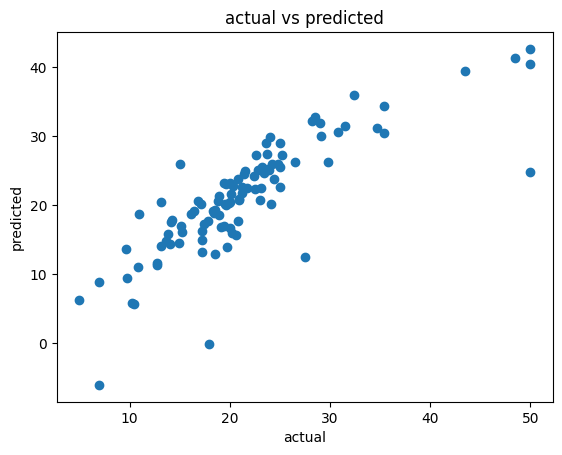

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("predicted")
plt.title("actual vs predicted")
plt.show()

In [ ]:
# import seaborn as sns
# plt.figure(figsize=(8,6))
# sns.scatterplot(x=y_test,y=y_pred,color="red")
# plt.xlabel("actual")
# plt.ylabel("predicted")
# # plt.title("actual vs predicted")
# plt.show()

### analysis of the scatter plot, Actual vs predicted prices
This plot compares the actual home prices(x-axis) with the predicted prices(y-axis) from our linear regression model.
- This plot compares:

#### observations
  - **strong positive correlation**
    - The point generally follow a diagonal trend indicating our model captured the overal pattern well.
  - **some spread**
    - There's some diversion from the perfect diagonal line(y=x), meaning our model has some error.
  - **outliers**
    - A few points are significantly particularly some predicted values that are much lower or higher than expected.

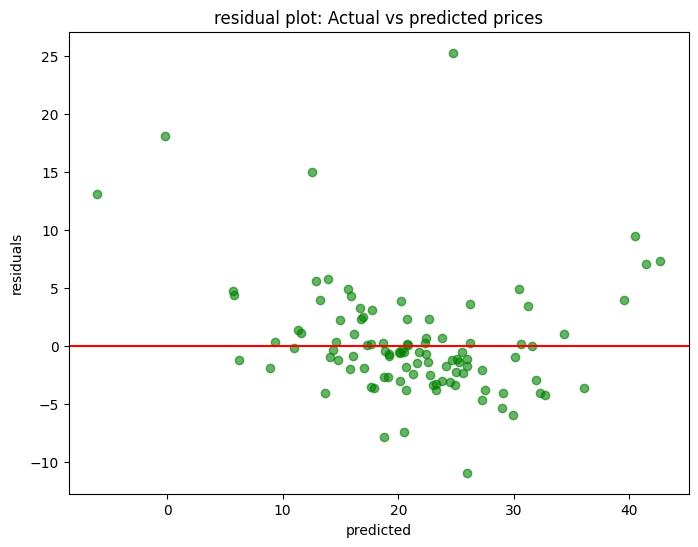

In [ ]:
## residual plot to check biasness
residuals=y_test-y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals, color = 'green', alpha = 0.6)
plt.axhline(y = 0, color = 'r', linestyle = '-', linewidth = 1.5)
plt.xlabel("predicted")
plt.ylabel("residuals")
plt.title("residual plot: Actual vs predicted prices")
plt.show()

## **Scattered residuals around 0**
This suggest that the linear regression model captures the general trend well

# **Polynomial regression**
This is an extension of regression that captures non-linearity

#### We follow these steps:
  - Step 1: Transform features by adding polynomial terms.
  - Step 2: Fit the model using polynomial regression.
  - Step 3: Evaluate the model usong mse, rmse, and r2.
  - Step 4: Visualize the actual vs predicted.

# 1. Step 1: Transforming features by adding polynomial terms.

In [ ]:
## loading libraries for transformation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
## defining polynomial degree
degree = 2
## creating polynomial features
poly_features = PolynomialFeatures(degree=degree, include_bias = False)
##  creating pipeline:
## polynomial transformation + features
model = make_pipeline(poly_features, LinearRegression())
# ## transforming features
# x_train_poly = poly_features.fit_transform(x_train)
# x_test_poly = poly_features.transform(x_test)

# Step 2: Fit the model using polynomial regression then predict

In [ ]:
## fitting the model
model.fit(x_train, y_train)
## predicting the model
y_pred_poly = model.predict(x_test)


# Step 3: Evaluating the model using mse, rmse, and r2

In [ ]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"polynomial regression(degree = {degree}) Result:")
print(f"MSE: {mse_poly: .2f}")
print(f"RMSE: {rmse_poly: .2f}")
print(f"R2: {r2_poly: .2f}")

polynomial regression(degree = 2) Result:
MSE:  14.26
RMSE:  3.78
R2:  0.81


#### comparing this to the linear regression results
  - mse dropped from 24.29 to 14.26(lower mse is better).
  - rmse dropped from 4.93 to 3.78(lower rmse is better).
  - r2 increased from 0.627 to 0.81(closer to 1.0 is better).
  - this suggest that polynomial regression(degree = 2) fits the data better than  simple linear regression.

  ## Step 4: Visualizing actual vs predicted prices.

---



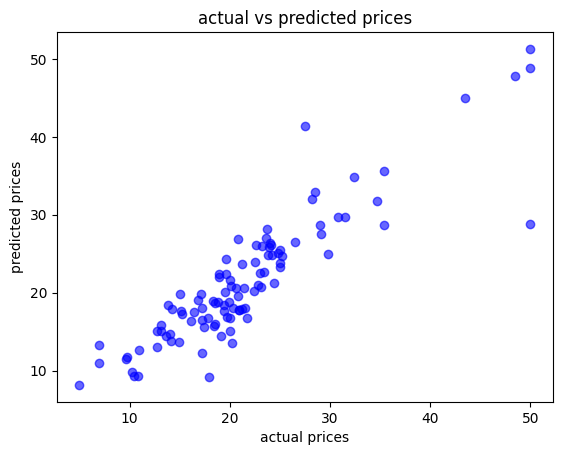

In [ ]:
## plot actual vs predicted prices
plt.scatter(y_test,y_pred_poly, color = 'blue', alpha = 0.6)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual vs predicted prices")
plt.show()

# Step 5: Visualizing the residual.

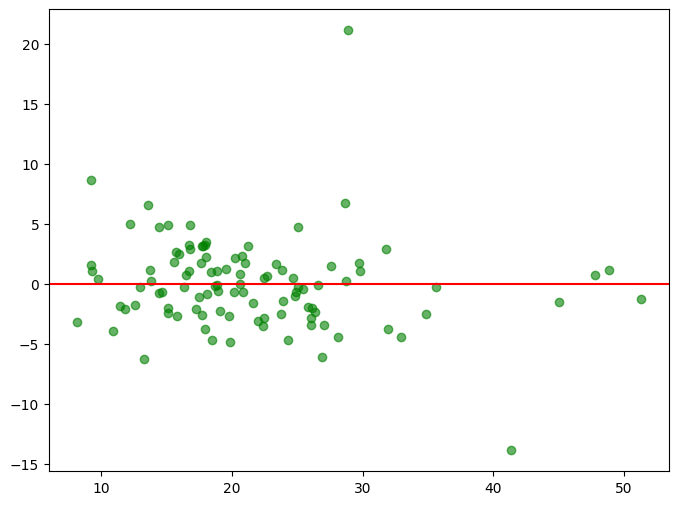

In [ ]:
## plot residual
residuals_poly = y_test - y_pred_poly
plt.figure(figsize=(8,6))
plt.scatter(y_pred_poly,residuals_poly, color = 'green', alpha = 0.6)
plt.axhline(y = 0, color = 'r', linestyle = '-', linewidth = 1.5)

## Interpretation
The residual looks more centered around zero indicating the polynomial model is capturing some non-linearity in the data

# Random forest
### Train the random forest model
  - Import RandomForestRegressor.
  - Set hyper-parameters (eg: number of trees, max depth).
  - Train the model on the training set.

### Make predictions
  - Use the trained model to make predictions on the test set

### Evaluate the model
  - Use rmse, r2, and mse.

### Hyper-parameter tuning(Optional)
  - Optimize parameters using grid search or random search to improve performance.

In [ ]:
## performing random forest modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
## model training
model_forest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_forest.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [ ]:
## making predictions
y_pred_forest = model_forest.predict(x_test)

In [ ]:
## evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_forest)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_forest)
print(f"RandomForest regression Results: ")
print(f"MSE: {mse_rf: .2f}")
print(f"RMSE: {rmse_rf: .2f}")
print(f"R2: {r2_rf: .2f}")


RandomForest regression Results: 
MSE:  7.76
RMSE:  2.79
R2:  0.89


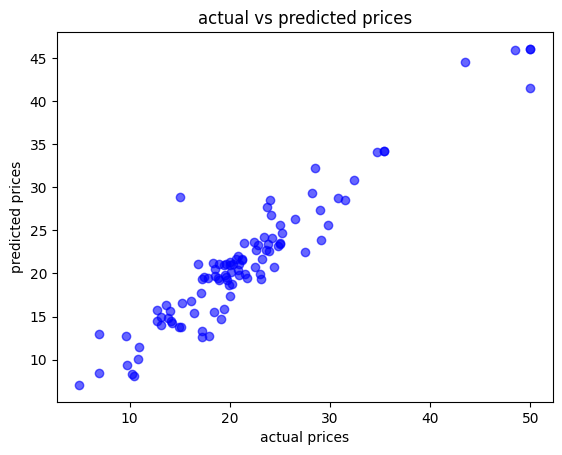

In [ ]:
## visualize the random forest
plt.scatter(y_test,y_pred_forest, color = 'blue', alpha = 0.6)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual vs predicted prices")
plt.show()

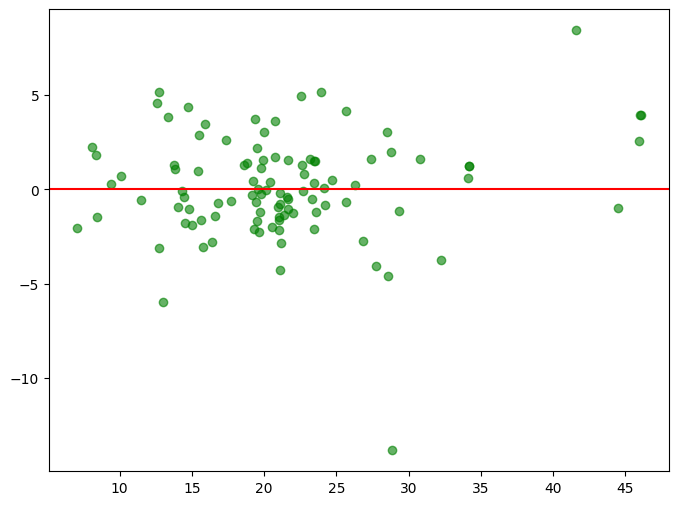

In [ ]:
## visualize the residual
residuals_forest = y_test - y_pred_forest
plt.figure(figsize=(8,6))
plt.scatter(y_pred_forest,residuals_forest, color = 'green', alpha = 0.6)
plt.axhline(y = 0, color = 'r', linestyle = '-', linewidth = 1.5)

# Decision tree


In [ ]:
## importing neccessary libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
## initializing DecisionTreeRegressor
dt_regressor = DecisionTreeRegressor(max_depth=10, random_state=42)
## fitting the model
dt_regressor.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
## predicting the model
y_pred_dt = dt_regressor.predict(x_test)

In [ ]:
## evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"DecisionTreeRegression Results: ")
print(f"MSE: {mse_dt: .2f}")
print(f"RMSE: {rmse_dt: .2f}")
print(f"R2: {r2_dt: .2f}")


DecisionTreeRegression Results: 
MSE:  22.53
RMSE:  4.75
R2:  0.69


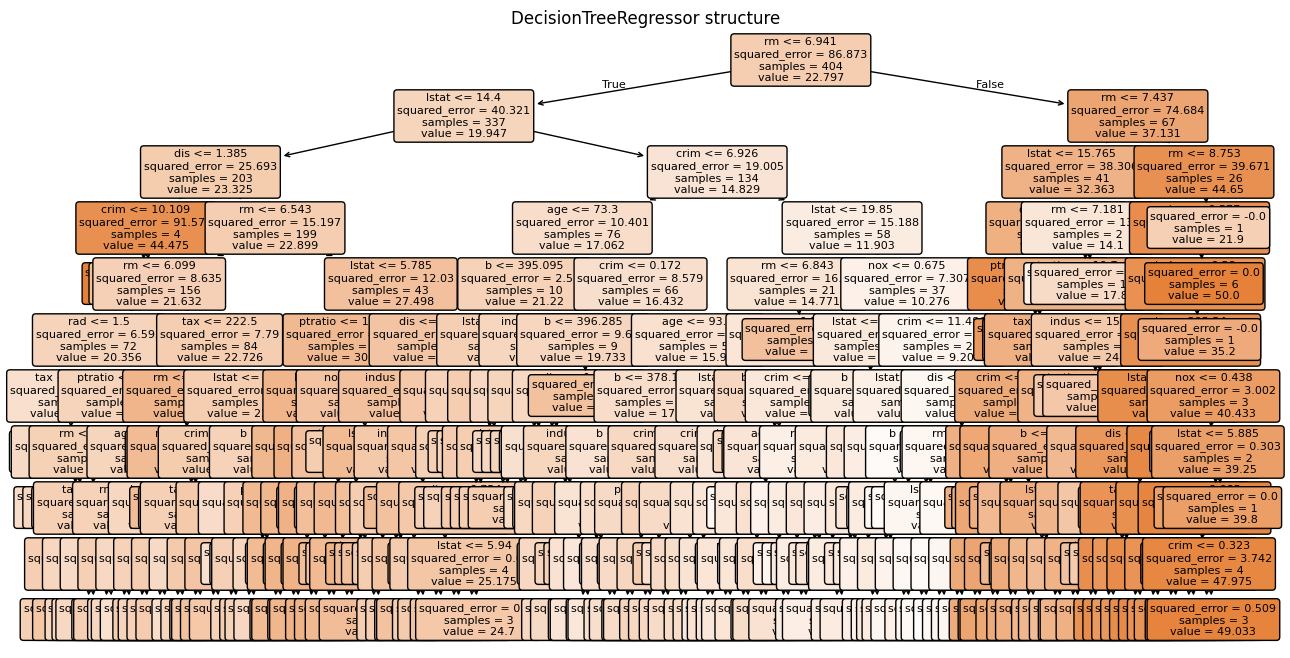

In [ ]:
## visualize the DecisionTreeRegressor
from sklearn.tree import plot_tree
plt.figure(figsize=(15,8))
plot_tree(dt_regressor, filled=True, feature_names=x_train.columns, rounded = True, fontsize = 8)
plt.title("DecisionTreeRegressor structure")
plt.show()

### Decision tree interpretation
  - **tree complexity**: the decision tree is deep indicating it may be overfitting to the training data.
  - **feature importance**: key predictors include LSTAT(lower income), RN(number of rooms), CRIM(crime rate) are all strong indicators of housing prices.
  - **splitting criteria**: the model makes decisions at different feature threshhold splitting the data to minimize variance and error.
  - **over fitting risk**: many leaf lots contain very few samples suggesting the model may be numerizing rather than generalizing.
  - **Next steps**: consider prunning or using random forest for improved generalization and stability.

## Key observations
1. random forest has a lower mse and rmse.
2. random forest has a higher r2 score.
3. why is random forest better?
  - a. reduces over fitting: decisionTree often overfits the training data capturing noice instead of patterns. RandomForest averages multiple trees making it more robust and generalizable.
  - b. better performance: combining multiple trees allows RandomForest to make more accurate descisions than a single DecisionTree.
  - c. if computation cost is not n issue, RandomForest is the best choice for regression task.


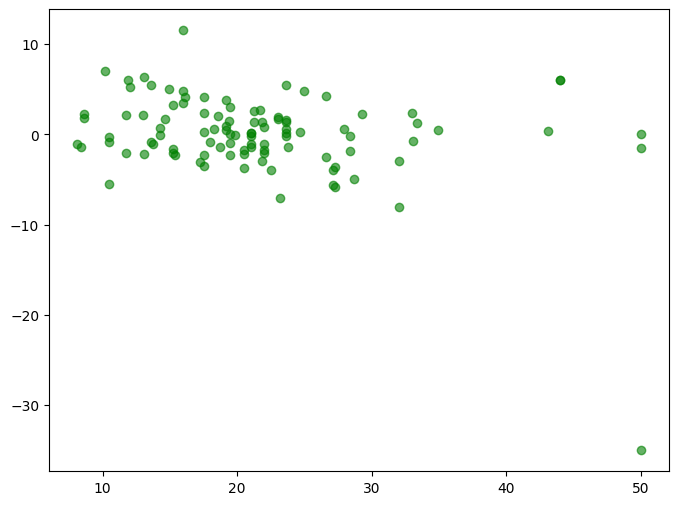

In [ ]:
## visualize the residual
residuals_dt = y_test - y_pred_dt
plt.figure(figsize=(8,6))
plt.scatter(y_pred_dt,residuals_dt, color = 'green', alpha = 0.6)

# classification
- logistic regression
- decision tree
- random forest
- support vector machine (SVM)
- K-nearest neighbour(KNN)
- neural networks
## Evaluation metrics
- accuracy
- recall, precision, F1-score

## Classification
### Logistic regression
### titanic dataset
### predicting survival

- The titanic dataset contains info about passengers in the RMS titanic including demographic details, ticket class, and survival status.
- It is commonly used for a binary classification problems where the goal is to predict whether a passenger survives(1) or not(0) based on various features.

#### Objectives
The goal of this project is to train a classification model(logistic regression) to predict whether a passenger survived the titanic disaster based on their attributes


In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## reading the titanic dataset
titanic = pd.read_csv("titanic.csv")

In [ ]:
## viewing 10 rows
titanic.head(10)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
## summary statistics
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    object 
 4   Name         891 non-null    object 
 5   Sex          891 non-null    object 
 6   Age          714 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    object 
 10  Fare         891 non-null    float64
 11  Cabin        204 non-null    object 
 12  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [ ]:
'''
1. change the pclass from object to int,
'''
## checking for missing
titanic.isnull().sum()

,0
Unnamed: 0,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0


### There are missing values in the dataset:
   - age: 177 missing
   - cabin: 687(most of the data missing)
   - embarked: 2 missing values

### Handling missing values

In [ ]:
## dropping the cabin variables(too many missing values)
titanic.drop("Cabin",axis=1,inplace=True)

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    object 
 4   Name         891 non-null    object 
 5   Sex          891 non-null    object 
 6   Age          714 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    object 
 10  Fare         891 non-null    float64
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
## filling the missing age var with the median
titanic["Age"].fillna(titanic["Age"].median(),inplace=True)


/tmp/ipython-input-43-3037487397.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Age"].fillna(titanic["Age"].median(),inplace=True)


In [ ]:
titanic.isnull().sum()

,0
Unnamed: 0,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0


In [ ]:
titanic.head(10)

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [ ]:
## filling the missing values in embarked with the mode
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0],inplace=True)

/tmp/ipython-input-46-3413947319.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["Embarked"].fillna(titanic["Embarked"].mode()[0],inplace=True)


In [ ]:
titanic.isnull().sum()


,0
Unnamed: 0,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0


## The survival rate
Use 0 for deaths and 1 for survival

In [ ]:
## survived
titanic['Survived'].value_counts()

,count
Survived,
0,549
1,342


## Gender count

In [ ]:
titanic['Sex'].value_counts()

,count
Sex,
male,577
female,314


## visualizing survival by sex




<Axes: xlabel='Sex', ylabel='count'>

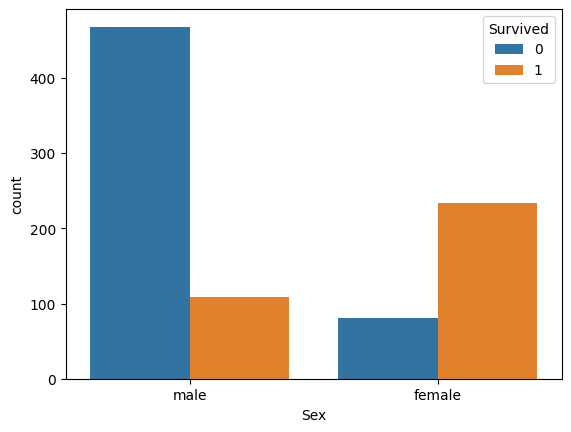

In [ ]:
## visualizing survival rate by sex
sns.countplot(x='Sex', hue = 'Survived', data = titanic)

## Inconsistencies


In [ ]:
## checking for inconsistencies
titanic['Pclass'].unique()

array(['3', '1', '2', '?'], dtype=object)

Replacing the '?' with a null value(NaN)

In [ ]:
titanic['Pclass'] = titanic['Pclass'].replace("?", np.nan)

In [ ]:
## converting from string to int
titanic['Pclass'] = titanic['Pclass'].astype(float)

In [ ]:
## filling the missing with the mode then converting to int
titanic['Pclass'] = titanic['Pclass'].fillna(titanic['Pclass'].mode()[0]).astype(int)

Verifying that Pclass is now an int

In [ ]:
print(titanic['Pclass'].dtype)

int64


In [ ]:
print(titanic['Pclass'].unique())

[3 1 2]


<Axes: xlabel='Pclass', ylabel='count'>

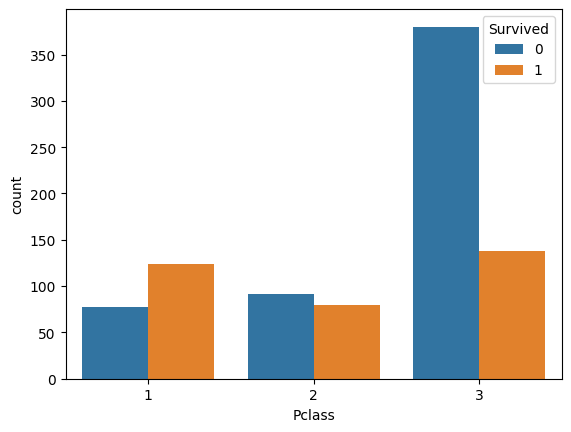

In [ ]:
## visualizing Pclass with survival
sns.countplot(x='Pclass', hue = 'Survived', data = titanic)

#

In [ ]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
model_dt = DecisionTreeClassifier()

# Fit the model to the training data
model_dt.fit(x_train, y_train)

# Predict on the test data
y_pred_dt = model_dt.predict(x_test)


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
## importing DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

## initializing DecisionTreeRegressor
dt_regressor = DecisionTreeRegressor(max_depth=10, random_state=42)

## fitting the model
dt_regressor.fit(x_train, y_train)

## predicting the model
y_pred_dt = dt_regressor.predict(x_test)

## evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"DecisionTreeRegression Results: ")
print(f"MSE: {mse_dt: .2f}")
print(f"RMSE: {rmse_dt: .2f}")
print(f"R2: {r2_dt: .2f}")

DecisionTreeRegression Results: 
MSE:  22.53
RMSE:  4.75
R2:  0.69


### key observations
  - top of the tree (root nodes):
    - the first plate is the most important feature  - likely sex, fare, or Pclass in the titanic dataset.
    - this means the model start by separating passangers based on that feature - for titanic. Sex is usually the most informative.
  - branching parts:
    - each left branch follows the root feature <= threshold.
    - each rif=ght branch follows the feature are => than threshold.
    - nodes with lower ginea are more 'pure' (mostly one class)

  - leaf nodes(bottom boxes):
    - these are the final decisions
    - nodes with value = [0, x] are predicted survived.
    - nodes with value = [x, 0] predicted died.

[Text(0.6335907567049809, 0.9545454545454546, 'rm <= 6.941\nsquared_error = 86.873\nsamples = 404\nvalue = 22.797'),
 Text(0.34369013409961685, 0.8636363636363636, 'lstat <= 14.4\nsquared_error = 40.321\nsamples = 337\nvalue = 19.947'),
 Text(0.4886404454022989, 0.9090909090909092, 'True  '),
 Text(0.1257183908045977, 0.7727272727272727, 'dis <= 1.385\nsquared_error = 25.693\nsamples = 203\nvalue = 23.325'),
 Text(0.07016283524904214, 0.6818181818181818, 'crim <= 10.109\nsquared_error = 91.577\nsamples = 4\nvalue = 44.475'),
 Text(0.06633141762452108, 0.5909090909090909, 'squared_error = 0.0\nsamples = 3\nvalue = 50.0'),
 Text(0.07399425287356322, 0.5909090909090909, 'squared_error = -0.0\nsamples = 1\nvalue = 27.9'),
 Text(0.18127394636015326, 0.6818181818181818, 'rm <= 6.543\nsquared_error = 15.197\nsamples = 199\nvalue = 22.899'),
 Text(0.08165708812260536, 0.5909090909090909, 'rm <= 6.099\nsquared_error = 8.635\nsamples = 156\nvalue = 21.632'),
 Text(0.029693486590038315, 0.5, 'rad

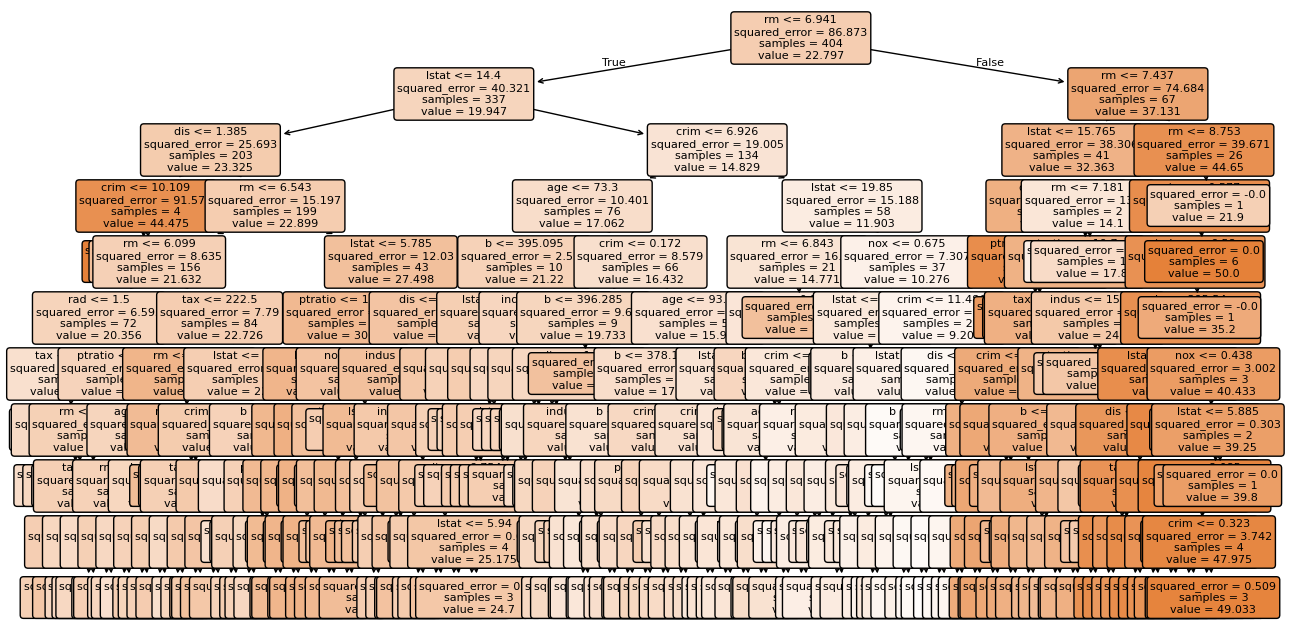

In [ ]:
#plot the decisionTreeClassifier
from sklearn.tree import plot_tree
plt.figure(figsize=(15,8))
plot_tree(dt_regressor, filled=True, feature_names=x_train.columns, rounded = True, fontsize = 8)